# Gemma 4 Audio Reasoning

This notebook loads Gemma 4 E4B and sends an audio + text prompt with reasoning enabled.

Run the setup cell first. The current environment has an older `transformers` install that is incompatible with the installed `huggingface_hub`, so the upgrade is required before loading the model.

Replace `AUDIO_PATH` with a real clip before using this for analysis. `data/silence.wav` is only a placeholder smoke test file.

In [1]:
# Run this once, then restart the kernel so the upgraded packages are picked up.
%pip install -q transformers librosa accelerate soundfile datasets scikit-learn pandas pyarrow scipy seaborn matplotlib einops git+https://github.com/davidbau/baukit

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from transformers import AutoModelForMultimodalLM, AutoProcessor

MODEL_ID = "/project/jevans/tzhang3/models/gemma-4-E4B-it"
# Alternative:
# MODEL_ID = "google/gemma-4-E4B-it"

AUDIO_SOURCE = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/Demos/sample-data/journal1.wav"
USER_PROMPT = (
    "Listen carefully to the audio. First transcribe any speech in its original "
    "language. Then briefly explain the main sounds you hear and your confidence."
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "audio", "audio": AUDIO_SOURCE},
            {"type": "text", "text": USER_PROMPT},
        ],
    }
]

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto",
)
model.eval()

print(f"Using model: {MODEL_ID}")
print(f"Audio source: {AUDIO_SOURCE}")

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

Using model: /project/jevans/tzhang3/models/gemma-4-E4B-it
Audio source: https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/Demos/sample-data/journal1.wav


In [3]:
def run_audio_prompt(messages, max_new_tokens: int = 512):
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
    ).to(model.device)
    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=1.0,
            top_p=0.95,
            top_k=64,
        )

    response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

    try:
        parsed_response = processor.parse_response(response)
    except Exception:
        parsed_response = response

    return response, parsed_response

raw_response, parsed_response = run_audio_prompt(messages)
parsed_response

{'role': 'assistant',
 'content': 'Okay, here\'s the transcription:\n\n"Okay, woke up today feeling refreshed. The morning light was beautiful, and I enjoyed a nice cup of coffee."\n\n**Explanation:**\n\nThe audio is a casual, spoken-word narration. The sounds I hear are clear and well-defined, consisting of a single voice speaking at a normal conversational pace. There are no background noises that interfere with the speech.\n\n**Confidence:**\n\nI am highly confident in this transcription. The speech is clear, and the content is easy to understand.\n'}

## Silence Direction Probe

The next cells build a balanced sound-vs-silence dataset from the local AudioSet and Speech/Noise datasets, extract Gemma 4 last-token head activations with the same tracing procedure used in `utils.py`, train an L2 logistic probe for each attention head, and report per-head accuracy.

In [4]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from datasets import Audio, Dataset, load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

from lpl.utils import extract_features, model_base_name, save_features, set_seed

set_seed(42)

AUDIOSET_DIR = Path("datasets/AudioSet")
SPEECH_NOISE_DIR = Path("datasets/speech-noise-dataset")
PROBE_PREFIX = "audio_silence"
PROBE_AUDIO_DIR = Path("data/audio_silence_probe")
PROBE_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

MAX_AUDIOSET_SAMPLES = 32
MAX_SPEECH_NOISE_SAMPLES = 32
MAX_SECONDS = 10.0
N_SPLITS = 5
RIDGE_ALPHA = 1.0

# Keep HF Datasets from writing large caches in home by using streaming reads for parquet.
os.environ.setdefault("HF_DATASETS_OFFLINE", "1")

device = next(model.parameters()).device
results_dir = Path("results") / model_base_name(MODEL_ID)
results_dir.mkdir(parents=True, exist_ok=True)

Set seed 42


In [5]:
def load_local_audioset(max_samples: int):
    iterable = load_dataset(
        "parquet",
        data_files={"train": str(AUDIOSET_DIR / "data" / "bal_train" / "*.parquet")},
        split="train",
        streaming=True,
    )

    selected = []
    for example in iterable:
        human_labels = set(example.get("human_labels") or [])
        if bool(human_labels) and "Silence" not in human_labels:
            selected.append(example)
            if len(selected) >= max_samples:
                break

    if not selected:
        raise RuntimeError("No AudioSet examples matched the non-silence filter.")

    return Dataset.from_list(selected).cast_column("audio", Audio())


def load_local_speech_noise(max_samples: int):
    iterable = load_dataset(
        "parquet",
        data_files={"train": str(SPEECH_NOISE_DIR / "data" / "train-*.parquet")},
        split="train",
        streaming=True,
    )

    selected = []
    for example in iterable:
        selected.append(example)
        if len(selected) >= max_samples:
            break

    if not selected:
        raise RuntimeError("No examples found in speech-noise parquet shards.")

    return Dataset.from_list(selected).cast_column("audio", Audio())


def trim_audio(audio_item, max_seconds: float = MAX_SECONDS):
    array = np.asarray(audio_item["array"], dtype=np.float32)
    if array.ndim > 1:
        array = array.mean(axis=1)
    sample_rate = int(audio_item["sampling_rate"])
    max_len = max(1, int(max_seconds * sample_rate))
    return array[:max_len], sample_rate


def write_probe_pair(array: np.ndarray, sample_rate: int, stem: str):
    sound_path = PROBE_AUDIO_DIR / f"{stem}_sound.wav"
    silence_path = PROBE_AUDIO_DIR / f"{stem}_silence.wav"
    sf.write(sound_path, array, sample_rate)
    sf.write(silence_path, np.zeros_like(array), sample_rate)
    return sound_path, silence_path


audioset_ds = load_local_audioset(MAX_AUDIOSET_SAMPLES)
speech_noise_ds = load_local_speech_noise(MAX_SPEECH_NOISE_SAMPLES)

records = []

for idx, example in enumerate(tqdm(audioset_ds, desc="AudioSet samples")):
    array, sample_rate = trim_audio(example["audio"])
    if array.size == 0 or np.max(np.abs(array)) == 0.0:
        continue
    sound_path, silence_path = write_probe_pair(array, sample_rate, f"audioset_{idx:04d}")
    description = ", ".join(example.get("human_labels") or []) or "AudioSet clip"
    records.extend(
        [
            {"source": "audioset", "audio_path": str(sound_path), "label": 1, "label_name": "sound", "description": description},
            {"source": "audioset", "audio_path": str(silence_path), "label": 0, "label_name": "silence", "description": "Synthetic silence matched to AudioSet clip"},
        ]
    )

for idx, example in enumerate(tqdm(speech_noise_ds, desc="Speech/noise samples")):
    array, sample_rate = trim_audio(example["audio"])
    if array.size == 0 or np.max(np.abs(array)) == 0.0:
        continue
    sound_path, silence_path = write_probe_pair(array, sample_rate, f"speech_noise_{idx:04d}")
    description = str(example.get("label") or "speech-noise clip")
    records.extend(
        [
            {"source": "speech_noise", "audio_path": str(sound_path), "label": 1, "label_name": "sound", "description": description},
            {"source": "speech_noise", "audio_path": str(silence_path), "label": 0, "label_name": "silence", "description": "Synthetic silence matched to speech/noise clip"},
        ]
    )

contrastive_df = pd.DataFrame(records).sample(frac=1.0, random_state=42).reset_index(drop=True)
if contrastive_df.empty:
    raise RuntimeError("No probe examples were created from the local audio datasets.")

display(contrastive_df.head())
display(contrastive_df.groupby(["source", "label_name"]).size().rename("count").reset_index())
print(f"Total examples: {len(contrastive_df)}")

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

AudioSet samples:   0%|          | 0/32 [00:00<?, ?it/s]

Speech/noise samples:   0%|          | 0/32 [00:00<?, ?it/s]

,source,audio_path,label,label_name,description
0,audioset,data/audio_silence_probe/audioset_0027_silence...,0,silence,Synthetic silence matched to AudioSet clip
1,audioset,data/audio_silence_probe/audioset_0020_sound.wav,1,sound,"Organ, Electronic organ"
2,audioset,data/audio_silence_probe/audioset_0009_silence...,0,silence,Synthetic silence matched to AudioSet clip
3,audioset,data/audio_silence_probe/audioset_0015_silence...,0,silence,Synthetic silence matched to AudioSet clip
4,speech_noise,data/audio_silence_probe/speech_noise_0017_sou...,1,sound,clean_speech


,source,label_name,count
0,audioset,silence,32
1,audioset,sound,32
2,speech_noise,silence,32
3,speech_noise,sound,32


Total examples: 128


In [6]:
model.model.language_model.layers[0].self_attn

Gemma4TextAttention(
  (q_norm): Gemma4RMSNorm()
  (k_norm): Gemma4RMSNorm()
  (v_norm): Gemma4RMSNorm()
  (k_proj): Linear(in_features=2560, out_features=512, bias=False)
  (q_proj): Linear(in_features=2560, out_features=2048, bias=False)
  (v_proj): Linear(in_features=2560, out_features=512, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2560, bias=False)
  (head_out): Identity()
)

In [12]:
PROBE_PROMPT = (
    "Describe the audio clip in detail. "
)


def build_probe_messages(audio_path: str):
    return [
        {
            "role": "user",
            "content": [
                {"type": "audio", "audio": audio_path},
                {"type": "text", "text": PROBE_PROMPT},
            ],
        }
    ]


encoded_prompts = [
    processor.apply_chat_template(
        build_probe_messages(audio_path),
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
    )
    for audio_path in tqdm(contrastive_df["audio_path"], desc="Encoding prompts")
]

labels = contrastive_df["label"].astype(np.int64).tolist()
features = extract_features(
    model=model,
    prompts=encoded_prompts,
    device=device,
    mode="vision",
)
save_features(
    features=features,
    labels=labels,
    model_path=MODEL_ID,
    output_dir="results",
    prefix=PROBE_PREFIX,
    save_as_numpy=False,
 )

print(f"Feature tensor shape: {features.shape}")

Encoding prompts:   0%|          | 0/128 [00:00<?, ?it/s]

Extracting features:   0%|          | 0/128 [00:00<?, ?it/s]

Saved features and labels to results/gemma-4-e4b-it/audio_silence_features.pkl
Feature tensor shape: (128, 1, 42, 8, (256, 256, 256, 256, 256, 512, 256, 256, 256, 256, 256, 512, 256, 256, 256, 256, 256, 512, 256, 256, 256, 256, 256, 512, 256, 256, 256, 256, 256, 512, 256, 256, 256, 256, 256, 512, 256, 256, 256, 256, 256, 512))


In [13]:
def train_logistic_head_probes(
    features: np.ndarray,
    labels: list[int],
    alpha: float = RIDGE_ALPHA,
    n_splits: int = N_SPLITS,
    seed: int = 42,
 ):
    labels = np.asarray(labels, dtype=np.int64)
    _, _, n_layers, n_heads, _ = features.shape
    performance = np.zeros((n_layers, n_heads), dtype=np.float32)
    probe_models = {}
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    c_value = 1.0 / alpha if alpha > 0 else 1e6

    for layer_idx in tqdm(range(n_layers), desc="Training logistic probes"):
        probe_models[layer_idx] = {}
        for head_idx in range(n_heads):
            X = features[:, 0, layer_idx, head_idx, :]
            fold_scores = []

            for train_idx, test_idx in splitter.split(X, labels):
                clf = LogisticRegression(
                    penalty="l2",
                    C=c_value,
                    fit_intercept=False,
                    solver="liblinear",
                    max_iter=2000,
                )
                clf.fit(X[train_idx], labels[train_idx])
                preds = clf.predict(X[test_idx])
                fold_scores.append(accuracy_score(labels[test_idx], preds))

            performance[layer_idx, head_idx] = float(np.mean(fold_scores))

            final_clf = LogisticRegression(
                penalty="l2",
                C=c_value,
                fit_intercept=False,
                solver="liblinear",
                max_iter=2000,
            )
            final_clf.fit(X, labels)
            probe_models[layer_idx][head_idx] = final_clf

    return performance, probe_models


silence_performance, silence_probe_models = train_logistic_head_probes(
    features=features,
    labels=labels,
    alpha=RIDGE_ALPHA,
    n_splits=N_SPLITS,
    seed=42,
 )

with open(results_dir / f"{PROBE_PREFIX}_logreg_performance.pkl", "wb") as handle:
    pickle.dump(silence_performance, handle)
with open(results_dir / f"{PROBE_PREFIX}_logreg.pkl", "wb") as handle:
    pickle.dump(silence_probe_models, handle)

Training logistic probes:   0%|          | 0/42 [00:00<?, ?it/s]

/home/tzhang3/envs/linear-probe/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tzhang3/envs/linear-probe/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tzhang3/envs/linear-probe/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

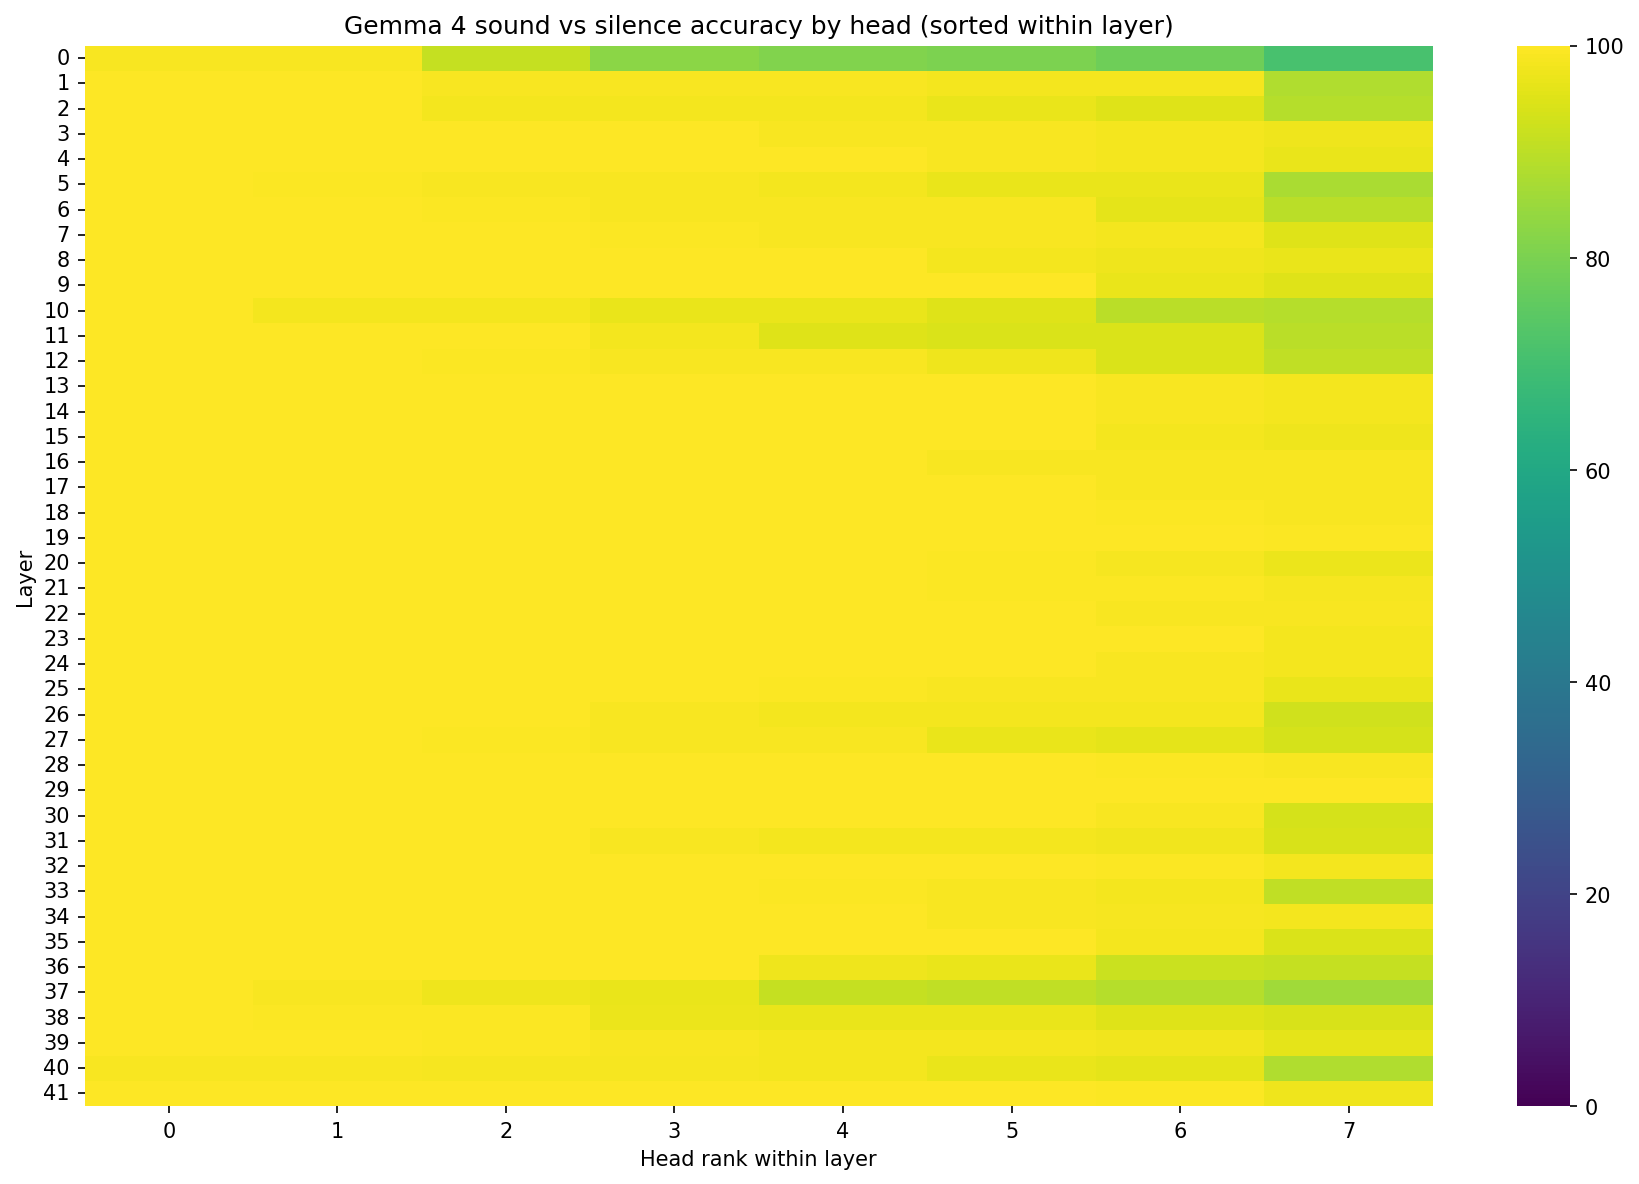

,layer,head,accuracy,accuracy_percent
0,2,0,1.0,100.0
1,41,7,1.0,100.0
2,41,6,1.0,100.0
3,41,1,1.0,100.0
4,41,3,1.0,100.0
5,41,4,1.0,100.0
6,41,0,1.0,100.0
7,36,7,1.0,100.0
8,36,2,1.0,100.0
9,36,1,1.0,100.0


Best head: layer 2, head 0, accuracy=1.000
Silence direction shape: (1, 256)


In [15]:
accuracy_df = (
    pd.DataFrame(silence_performance)
    .rename_axis(index="layer", columns="head")
    .stack()
    .rename("accuracy")
    .reset_index()
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)
accuracy_df["accuracy_percent"] = accuracy_df["accuracy"] * 100.0

best_layer = int(accuracy_df.loc[0, "layer"])
best_head = int(accuracy_df.loc[0, "head"])
sound_direction = silence_probe_models[best_layer][best_head].coef_.astype(np.float32).copy()
silence_direction = -sound_direction

sorted_performance = np.sort(silence_performance * 100.0, axis=1)[:, ::-1]

plt.figure(figsize=(12, 8), dpi=150)
sns.heatmap(sorted_performance, cmap="viridis", vmin=0, vmax=100)
plt.title("Gemma 4 sound vs silence accuracy by head (sorted within layer)")
plt.xlabel("Head rank within layer")
plt.ylabel("Layer")
plt.tight_layout()
plt.show()

display(accuracy_df.head(20))
print(f"Best head: layer {best_layer}, head {best_head}, accuracy={accuracy_df.loc[0, 'accuracy']:.3f}")
print(f"Silence direction shape: {silence_direction.shape}")

## Steering With Learned Probe Coefficients

The next cell uses the learned linear probe coefficients to steer Gemma 4 on a few audio prompts.

It compares three settings:
- Baseline generation
- Steering with the global top 16 heads by probe accuracy
- Steering with all heads from the middle third of layers

The code uses the native per-layer head dimensions from the ragged feature tensors, so it does not pad coefficients across layers.

In [27]:
from baukit import TraceDict
from lpl.utils import get_head_out_key

STEERING_PROMPT = (
    "Describe what you hear."
)
STEERING_ALPHA = 100.0
STEERING_MAX_NEW_TOKENS = 96


def build_audio_messages(audio_path: str, prompt_text: str = STEERING_PROMPT):
    return [
        {
            "role": "user",
            "content": [
                {"type": "audio", "audio": audio_path},
                {"type": "text", "text": prompt_text},
            ],
        }
    ]


def parsed_to_text(parsed):
    if isinstance(parsed, str):
        return parsed
    if isinstance(parsed, dict):
        for key in ("content", "text", "response"):
            if key in parsed and parsed[key]:
                return parsed[key]
        return str(parsed)
    return str(parsed)


def run_multimodal_messages(messages, coeffs_by_layer=None, alpha: float = 0.0, max_new_tokens: int = 96):
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
    ).to(device)
    input_len = inputs["input_ids"].shape[-1]

    if coeffs_by_layer is None:
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )
    else:
        head_names = [get_head_out_key(layer_idx, "vision") for layer_idx in sorted(coeffs_by_layer)]

        def hook_fn(output, module_name):
            parts = module_name.split(".")
            layer_idx = int(parts[parts.index("layers") + 1])
            delta = coeffs_by_layer[layer_idx].to(device=output.device, dtype=output.dtype)
            output[:, -1, :, :] = output[:, -1, :, :] + alpha * delta
            return output

        with torch.inference_mode():
            with TraceDict(model, head_names, edit_output=hook_fn):
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                )

    response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
    try:
        parsed = processor.parse_response(response)
    except Exception:
        parsed = response
    return response, parsed_to_text(parsed)


def build_ragged_probe_coefs(
    ragged_features,
    probe_models,
    selections,
    direction: str = "sound",
    normalize: str = "sqrt",
):
    coeffs_by_layer = {}
    selections = [(int(layer_idx), int(head_idx)) for layer_idx, head_idx in selections]

    for layer_idx, head_idx in selections:
        layer_features = ragged_features[layer_idx]  # [N, T, H, D_i]
        n_heads = layer_features.shape[2]
        head_dim = layer_features.shape[3]
        if layer_idx not in coeffs_by_layer:
            coeffs_by_layer[layer_idx] = torch.zeros((n_heads, head_dim), dtype=torch.float32, device=device)

        coef = probe_models[layer_idx][head_idx].coef_.reshape(-1).astype(np.float32)
        coef = torch.from_numpy(coef).to(device)
        coef = coef * torch.from_numpy(layer_features[:, 0, head_idx, :].std(axis=0).astype(np.float32)).to(device)

        if direction == "silence":
            coef = -coef

        coeffs_by_layer[layer_idx][head_idx] = coef

    if normalize == "sqrt":
        scale = max(len(selections), 1) ** 0.5
    elif normalize == "mean":
        scale = max(len(selections), 1)
    else:
        scale = 1.0

    for layer_idx in coeffs_by_layer:
        coeffs_by_layer[layer_idx] = coeffs_by_layer[layer_idx] / scale

    return coeffs_by_layer


def pick_example(source: str, label_name: str, row_idx: int = 0):
    row = contrastive_df[(contrastive_df["source"] == source) & (contrastive_df["label_name"] == label_name)].iloc[row_idx]
    return {
        "name": f"{source}_{label_name}",
        "audio_path": row["audio_path"],
        "description": row["description"],
    }


interesting_audio_specs = [
    {
        "name": "journal_sample",
        "audio_path": AUDIO_SOURCE,
        "description": "Reference web audio clip",
    },
    pick_example("audioset", "sound"),
    pick_example("audioset", "silence"),
    pick_example("speech_noise", "sound"),
    pick_example("speech_noise", "silence"),
]

for spec in interesting_audio_specs:
    spec["messages"] = build_audio_messages(spec["audio_path"])


top16_indices = accuracy_df[["layer", "head"]].head(32).to_numpy(dtype=int)
num_layers = silence_performance.shape[0]
middle_start = num_layers // 3
middle_end = num_layers - middle_start
middle_layer_indices = accuracy_df.loc[
    accuracy_df["layer"].between(middle_start, middle_end - 1),
    ["layer", "head"],
].head(32).to_numpy(dtype=int)

top16_sound_coefs = build_ragged_probe_coefs(features, silence_probe_models, top16_indices, direction="sound")
middle_layer_sound_coefs = build_ragged_probe_coefs(
    features,
    silence_probe_models,
    middle_layer_indices,
    direction="sound",
)

rows = []
for spec in tqdm(interesting_audio_specs, desc="Steering prompts"):
    _, baseline_text = run_multimodal_messages(
        spec["messages"],
        coeffs_by_layer=None,
        max_new_tokens=STEERING_MAX_NEW_TOKENS,
    )
    _, top16_text = run_multimodal_messages(
        spec["messages"],
        coeffs_by_layer=top16_sound_coefs,
        alpha=STEERING_ALPHA,
        max_new_tokens=STEERING_MAX_NEW_TOKENS,
    )
    _, middle_text = run_multimodal_messages(
        spec["messages"],
        coeffs_by_layer=middle_layer_sound_coefs,
        alpha=STEERING_ALPHA,
        max_new_tokens=STEERING_MAX_NEW_TOKENS,
    )
    rows.append(
        {
            "prompt": spec["name"],
            "description": spec["description"],
            "baseline": baseline_text,
            "top16_sound_steer": top16_text,
            "middle_layers_sound_steer": middle_text,
        }
    )

steering_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 120)
print(f"Top-16 steering heads: {len(top16_indices)}")
print(f"Middle-layer steering heads: {len(middle_layer_indices)} (layers {middle_start}..{middle_end - 1})")
print(f"Steering alpha: {STEERING_ALPHA}")
display(steering_df)

Steering prompts:   0%|          | 0/5 [00:00<?, ?it/s]

Top-16 steering heads: 32
Middle-layer steering heads: 32 (layers 14..27)
Steering alpha: 100.0


,prompt,description,baseline,top16_sound_steer,middle_layers_sound_steer
0,journal_sample,Reference web audio clip,"I hear the sound of a morning ritual. The description suggests a peaceful and refreshing start to the day, with the ...",The sound of a morning ritual is what I hear. It sounds like a peaceful and refreshing start to the day.,I hear someone speaking. They sound cheerful and content.
1,audioset_sound,"Organ, Electronic organ",The sound I hear is of a dog barking.\n,The sound I hear is that of a drum. It has a rhythmic and percussive quality.\n,The sound is a recording of a dog barking.
2,audioset_silence,Synthetic silence matched to AudioSet clip,"I hear a gentle, rhythmic sound, like a soft, steady beat. It has a somewhat ambient quality, and it feels quite cal...","I hear a sound that sounds like a gentle, rhythmic tapping. It could be rain on a window, or perhaps a light knockin...","The sound is a low, continuous hum, possibly from an electrical device or machinery."
3,speech_noise_sound,clean_speech,"The speaker is discussing a fight between Glace and Tebo, mentioning that Glace might have lost to him. He also note...",The audio features a discussion about a fight between Glace and T-Bow. It mentions that Glace might have lost to him...,"Uh, to Glace and Tebo. He might have lost to him. Might have lost a round, and that was a controversial fight where ..."
4,speech_noise_silence,Synthetic silence matched to speech/noise clip,"I hear a gentle, rhythmic sound, like a soft, steady beat. It has a somewhat ambient quality, and it feels quite cal...","I hear a sound that sounds like a gentle, rhythmic tapping. It could be rain on a window, or perhaps a light knockin...","The sound is a low, continuous hum, possibly from an electrical device or machinery."


In [33]:
TEXT_STEERING_PROMPTS = [
    {
        "name": "art",
        "prompt": "Imagine you are drawing a painting. What are the main elements, colors, and mood?",
    },
    {
        "name": "monalisa",
        "prompt": "How would you describe the Mona Lisa?",
    },
    {
        "name": "bioluminescent_city",
        "prompt": "Describe a city where all light is generated biologically. How do the infrastructure, social habits, and architecture adapt to this dim, organic glow?",
    },
    {
        "name": "unusual_utility",
        "prompt": "List 20 creative and highly unconventional uses for a simple paperclip that have nothing to do with holding paper or picking locks.",
    },
    {
        "name": "alien_senses",
        "prompt": "Describe a sunset from the perspective of a creature that perceives the world through echolocation and magnetic fields rather than visible light.",
    },
    {
        "name": "alternative_physics",
        "prompt": "In a world where gravity works in reverse for objects colored blue, describe a typical morning commute in a busy city.",
    },
]

ALPHAS_TO_COMPARE = [-100, 100]


def build_text_messages(prompt_text: str):
    return [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt_text},
            ],
        }
    ]


text_rows = []
for spec in tqdm(TEXT_STEERING_PROMPTS, desc="Text-only steering prompts"):
    messages = build_text_messages(spec["prompt"])

    _, baseline_text = run_multimodal_messages(
        messages,
        coeffs_by_layer=None,
        max_new_tokens=STEERING_MAX_NEW_TOKENS,
    )

    row = {
        "prompt_name": spec["name"],
        "prompt": spec["prompt"],
        "baseline": baseline_text,
    }

    for alpha in ALPHAS_TO_COMPARE:
        _, top_text = run_multimodal_messages(
            messages,
            coeffs_by_layer=top16_sound_coefs,
            alpha=alpha,
            max_new_tokens=STEERING_MAX_NEW_TOKENS,
        )
        _, middle_text = run_multimodal_messages(
            messages,
            coeffs_by_layer=middle_layer_sound_coefs,
            alpha=alpha,
            max_new_tokens=STEERING_MAX_NEW_TOKENS,
        )

        row[f"top_heads_alpha_{alpha}"] = top_text
        row[f"middle_layers_alpha_{alpha}"] = middle_text

    text_rows.append(row)

text_steering_df = pd.DataFrame(text_rows)

# Show full text without clipping
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

styled = text_steering_df.style.set_properties(
    **{
        "white-space": "pre-wrap",
        "text-align": "left",
        "vertical-align": "top",
    }
)
display(styled)

# Plain-text fallback that never truncates
for _, r in text_steering_df.iterrows():
    print("\n" + "=" * 100)
    print(f"Prompt: {r['prompt_name']}")
    print(f"Text: {r['prompt']}")

    rows_for_prompt = [
        ("baseline", r["baseline"]),
        ("top_heads alpha=-100", r["top_heads_alpha_-100"]),
        ("top_heads alpha=100", r["top_heads_alpha_100"]),
        ("middle_layers alpha=-100", r["middle_layers_alpha_-100"]),
        ("middle_layers alpha=100", r["middle_layers_alpha_100"]),
    ]
    for setting, response in rows_for_prompt:
        print(f"\n[{setting}]\n{response}")

Text-only steering prompts:   0%|          | 0/6 [00:00<?, ?it/s]

,prompt_name,prompt,baseline,top_heads_alpha_-100,middle_layers_alpha_-100,top_heads_alpha_100,middle_layers_alpha_100
0,art,"Imagine you are drawing a painting. What are the main elements, colors, and mood?","## The Painting: ""Ephemeral Bloom"" As I begin to sketch out the canvas, I'm not aiming for a hyper-realistic scene, but rather an *impression*—a feeling captured in light and color. This piece is titled **""Ephemeral Bloom.""** Here is a breakdown of the main elements, colors, and mood I am cultivating: --- ### 🌿 Main Elements The composition is built around a central, dynamic interaction between nature and light","## The Painting: ""Whispers of the Coastal Dawn"" If I were to pick up a brush right now, I would be painting a landscape, but not a grand, sweeping vista. It would be an intimate, quiet moment captured just as the world is waking up. Here is a breakdown of the elements, colors, and mood: --- ### 🎨 Main Elements 1. **The Coastline:** This is the anchor of the painting. It features","Since I don't have eyes or a physical body, I have to *imagine* the painting! To give you the best description, I'll create a vivid mental image. Here is a description of a painting I am currently ""drawing"" in my mind: *** ## The Whispering Grove **Main Elements:** The scene is set in a **Whispering Grove** just as the sun begins its slow descent. The central focus is a cluster of","## The Painting: ""Ephemeral Dusk"" As I dip my brush, the canvas seems to breathe with anticipation. This painting, which I'm calling ""Ephemeral Dusk,"" is less about a specific moment and more about the *feeling* of transition—that beautiful, liminal space between day and night. Here are the main elements, colors, and mood I'm aiming for: --- ### 🎨 Main Elements 1. **The Horizon Line (The","## The Painting: ""Ephemeral Dawn"" **(Imagine a canvas that is both vibrant and deeply melancholic.)** --- ### 🎨 Main Elements: The composition is dominated by a **vast, dramatic landscape**. 1. **The Horizon Line:** A strong, slightly uneven horizon line divides the canvas, suggesting a sense of immense, perhaps overwhelming, space. 2. **The Sky:** This is the most dominant element. It is not a clear blue,"
1,monalisa,How would you describe the Mona Lisa?,"Describing the Mona Lisa is a complex task because its enduring fame stems not just from its technical mastery, but also from the mystery and cultural weight it carries. Here is a comprehensive description, broken down by different aspects: --- ### 1. The Visual & Technical Description **The Subject:** The painting is a portrait of a woman, widely believed to be **Lisa Gherardini**, the wife of a Florentine merchant named Francesco del Giocondo.","Describing the Mona Lisa is a complex task because it's not just a painting; it's a cultural phenomenon. However, I can provide a comprehensive description covering its **physical characteristics, artistic qualities, historical significance, and the elements that make it so famous.** Here is a detailed breakdown: --- ### 🎨 Physical Description * **Subject:** The painting is a portrait of a woman, widely believed to be **Lisa Gherardini**, the wife of","Describing the Mona Lisa is a fascinating challenge because it's a work of art, and art is inherently subjective. However, I can give you a comprehensive overview of what she is, what she looks like, and what makes her so famous. Here is a multi-faceted description, covering the **visuals, the technique, and the impact**: --- ### 🎨 The Visuals (What she looks like) If you are looking at a high-","The Mona Lisa, or *La Gioconda*, is arguably the most famous and recognizable painting in the world. Describing it is a complex task because its fame stems not just from its artistic merit, but also from its cultural mystique, history, and the sheer amount of attention it commands. Here is a comprehensive description, broken down into different aspects: --- ### 1. Visual Description (What you see) * **Subject:** The painti


Prompt: art
Text: Imagine you are drawing a painting. What are the main elements, colors, and mood?

[baseline]
## The Painting: "Ephemeral Bloom"

As I begin to sketch out the canvas, I'm not aiming for a hyper-realistic scene, but rather an *impression*—a feeling captured in light and color. This piece is titled **"Ephemeral Bloom."**

Here is a breakdown of the main elements, colors, and mood I am cultivating:

---

### 🌿 Main Elements

The composition is built around a central, dynamic interaction between nature and light

[top_heads alpha=-100]
## The Painting: "Whispers of the Coastal Dawn"

If I were to pick up a brush right now, I would be painting a landscape, but not a grand, sweeping vista. It would be an intimate, quiet moment captured just as the world is waking up.

Here is a breakdown of the elements, colors, and mood:

---

### 🎨 Main Elements

1. **The Coastline:** This is the anchor of the painting. It features

[top_heads alpha=100]
## The Painting: "Ephemeral Dusk"